# SPO Baseline — Oracle-based SPO+（对应原始 e2e_v5b_socp zeta_10）

本文件一一对应原始 v5b notebook：保留 SOCP mean–SD oracle、MLP、rolling window 与评价口径，只把训练主损失替换为 oracle-based SPO+ surrogate。


## 1. 配置

In [1]:
from pathlib import Path

# ── 相对路径：默认 notebook 与数据文件在同一目录 ───────────────────────────
# 如果你把数据放在 ./data/ 下，只需要改成 DATA_DIR = PROJECT_ROOT / "data"
PROJECT_ROOT = Path.cwd()
DATA_DIR     = PROJECT_ROOT
OUT_DIR      = PROJECT_ROOT / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

RAW_PATH   = DATA_DIR / 'hs300_factor_data_filled.parquet'
PANEL_PATH = DATA_DIR / 'factor_panel_v2_processed.parquet'
IC_PATH    = DATA_DIR / '03v3_ic_summary.csv'

# ── 因子筛选 ─────────────────────────────────────────────────────────────
IC_TSTAT_THRESHOLD = 2.0
MIN_COVERAGE       = 0.70
FWD_RET_COVERAGE   = 0.80

# ── 模型与训练参数（保持原文件口径）───────────────────────────────────────
HIDDEN_DIM = 32
SEED       = 42
N_WARM     = 10
N_E2E      = 60
LR_MSE     = 1e-3
LR_E2E     = 1e-4
GRAD_CLIP  = 1.0
BATCH_SIZE = 8

# ── 风险偏好参数（保持 v5b 口径）───────────────────────────────────────────
LAMBDA      = 1.0
LAMBDA_LIST = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
ZETA_TRAIN = 10.0
ALPHA_IC   = 0.05
MAX_W_FRAC = 10
TC_RATE    = 0.003
TRAIN_WINDOW = 36
STEP_SIZE    = 3

# ── SPO baseline 开关 ─────────────────────────────────────────────────────
SPO_RUN_NAME   = 'spo_plus_oracle_v5b_socp_zeta10'
SPO_LOSS_LABEL = 'Oracle-based SPO+ surrogate'
RUN_LAMBDA_SWEEP = True

print("=" * 72)
print(f"{SPO_RUN_NAME}")
print("=" * 72)
print(f"DATA_DIR     = {DATA_DIR}")
print(f"PANEL_PATH   = {PANEL_PATH}")
print(f"IC_PATH      = {IC_PATH}")
print(f"OUT_DIR      = {OUT_DIR}")
print(f"LOSS         = {SPO_LOSS_LABEL}")
print(f"N_WARM={N_WARM}, N_E2E={N_E2E}, BATCH_SIZE={BATCH_SIZE}")


spo_plus_oracle_v5b_socp_zeta10
DATA_DIR     = I:\A大四秋招\run
PANEL_PATH   = I:\A大四秋招\run\factor_panel_v2_processed.parquet
IC_PATH      = I:\A大四秋招\run\03v3_ic_summary.csv
OUT_DIR      = I:\A大四秋招\run\outputs
LOSS         = Oracle-based SPO+ surrogate
N_WARM=10, N_E2E=60, BATCH_SIZE=8


## 2. 导入与数据加载

In [2]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import warnings, time
from collections import Counter
from scipy.optimize import brentq
warnings.filterwarnings('ignore')

import torch, torch.nn as nn, torch.optim as optim, torch.nn.functional as F

torch.manual_seed(SEED); np.random.seed(SEED)
plt.rcParams['font.sans-serif'] = ['SimHei','Arial Unicode MS','DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False


def date_as_date(x):
    return pd.Timestamp(x).date()

def date_as_ym(x):
    return pd.Timestamp(x).strftime('%y-%m')

def date_as_Ym(x):
    return pd.Timestamp(x).strftime('%Y-%m')

panel = pd.read_parquet(PANEL_PATH)
panel['date'] = pd.to_datetime(panel['date'])
ic_df = pd.read_csv(IC_PATH, index_col=0)
if 'Sig(|t|>2)' in ic_df.columns:    sig_mask = ic_df['Sig(|t|>2)']
elif 't_stat' in ic_df.columns:       sig_mask = ic_df['t_stat'].abs() > IC_TSTAT_THRESHOLD
else: raise ValueError("IC 文件需含 t_stat 或 Sig(|t|>2) 列")
SIG_FACTORS = list(ic_df[sig_mask].index); N_FEATURES = len(SIG_FACTORS)
print(f"Factor panel: {panel.shape}  ({panel['date'].nunique()} months)")
print(f"显著因子 ({N_FEATURES} 个): {SIG_FACTORS}")
assert N_FEATURES >= 2

Factor panel: (21760, 105)  (68 months)
显著因子 (10 个): ['F91_ocf_ni', 'F97_accruals', 'F80_ocf_mv', 'F74_cfp', 'F55_holding_adj', 'F81_size', 'F34_vol_of_vol', 'F88_cash_roe', 'F41_turn_std', 'F30_range_vol']


## 3. 股票池 & 特征

In [3]:
all_dates = sorted(panel['date'].unique())
def get_valid_stocks(df, factors):
    return set(df.dropna(subset=factors + ['fwd_ret'])['ts_code'].unique())
month_valid = {d: get_valid_stocks(panel[panel['date']==d], SIG_FACTORS) for d in all_dates}
stock_cnt = Counter(s for v in month_valid.values() for s in v)
universe  = sorted(s for s,c in stock_cnt.items() if c/len(all_dates) >= MIN_COVERAGE)
N = len(universe); MAX_W = MAX_W_FRAC / N

panel_u = (panel[panel['ts_code'].isin(universe)].sort_values(['date','ts_code']).reset_index(drop=True))
for col in SIG_FACTORS:
    panel_u[col] = panel_u.groupby('date')[col].transform(
        lambda x: x.fillna(0 if x.isna().all() else x.mean()))
panel_u['fwd_ret'] = panel_u.groupby('date')['fwd_ret'].transform(
    lambda x: x.fillna(x.median() if not x.isna().all() else 0))
def cross_sec_zscore(arr):
    mu = arr.mean(0,keepdims=True); sig = np.maximum(arr.std(0,keepdims=True),1e-8)
    return np.nan_to_num((arr-mu)/sig).astype('float32')
fwd_cov = panel_u.groupby('date')['fwd_ret'].apply(lambda x: x.notna().mean())
dates_valid = [d for d in sorted(panel_u['date'].unique()) if fwd_cov.get(d,0) >= FWD_RET_COVERAGE]
X_tensors, y_tensors = [], []
for d in dates_valid:
    sub = panel_u[panel_u['date']==d].sort_values('ts_code')
    X_tensors.append(torch.tensor(cross_sec_zscore(sub[SIG_FACTORS].values)))
    y_tensors.append(torch.tensor(sub['fwd_ret'].values.astype('float32')))
T = len(X_tensors)
print(f"股票池: {N} 只   max_w = {MAX_W_FRAC}/N = {MAX_W:.4f}  有效月份: {T}")

股票池: 252 只   max_w = 10/N = 0.0397  有效月份: 68


## 4. 滚动窗口

In [4]:
rolling_windows = []
start = 0
while start + TRAIN_WINDOW + STEP_SIZE <= T:
    rolling_windows.append({
        'train_start': start,           'train_end': start + TRAIN_WINDOW,
        'test_start' : start + TRAIN_WINDOW,
        'test_end'   : min(start + TRAIN_WINDOW + STEP_SIZE, T),
    })
    start += STEP_SIZE

assert rolling_windows, f"数据不足，T={T}，需至少 {TRAIN_WINDOW + STEP_SIZE} 月"
fw, lw = rolling_windows[0], rolling_windows[-1]
n_test_total = sum(w['test_end'] - w['test_start'] for w in rolling_windows)

print(f"滚动窗口: {len(rolling_windows)} 个  累计测试月: {n_test_total}")
print(f"首: [{pd.Timestamp(dates_valid[fw['train_start']]).date()}~{pd.Timestamp(dates_valid[fw['train_end']-1]).date()}] → [{pd.Timestamp(dates_valid[fw['test_start']]).date()}~{pd.Timestamp(dates_valid[fw['test_end']-1]).date()}]")
print(f"末: 测试 [{pd.Timestamp(dates_valid[lw['test_start']]).date()}~{pd.Timestamp(dates_valid[lw['test_end']-1]).date()}]")


滚动窗口: 10 个  累计测试月: 30
首: [2020-04-30~2023-03-31] → [2023-04-28~2023-06-30]
末: 测试 [2025-07-31~2025-09-30]


## 5. 可微 SOCP 层（v5b 核心）

**与 v4/v5 的本质区别：**
- v4/v5 LP 层内层：$\min -\mu^\top w + \frac{\zeta}{2}\|w\|^2$（只有平滑项）
- **v5b SOCP 层内层：$\min -\mu^\top w + \lambda\sqrt{w^\top Dw} + \frac{\zeta}{2}\|w\|^2$**（含真实风险项）


In [5]:
# ── SOCP 前向求解器（固定点迭代）────────────────────────────────────────
def solve_socp_diag(mu_np, var_np, lambda_, max_w, zeta, max_iter=40, tol=1e-9):
    """
    求解: min_w  -μᵀw + λ·√(wᵀDw) + (ζ/2)·‖w‖²
          s.t.   Σwᵢ=1, 0 ≤ wᵢ ≤ max_w
    其中 D = diag(var_np).

    固定点迭代（每步用 brentq，通常 4-6 次收敛）：
      给定 P = √(wᵀDw)，per-stock 有效 ζᵢ = λσᵢ²/P + ζ
      wᵢ = clip((μᵢ − ν*) / ζᵢ_eff, 0, max_w)
      更新 P ← √(Σᵢ σᵢ² wᵢ²)，重复至 P 收敛。
    """
    n = len(mu_np)
    # 初始化 P：用纯 L2 平滑 LP 的解
    z0 = max(zeta, 1e-6)
    def lp_budget(nu): return np.clip((mu_np-nu)/z0, 0, max_w).sum()-1.0
    try:
        nu0 = brentq(lp_budget, mu_np.min()-max_w*z0-1, mu_np.max()+1, xtol=1e-10, maxiter=200)
        w0  = np.clip((mu_np-nu0)/z0, 0, max_w); w0 /= max(w0.sum(), 1e-10)
    except:
        w0 = np.ones(n) / n
    P = max(np.sqrt((w0**2 * var_np).sum()), 1e-8)

    w = w0.copy()
    for _ in range(max_iter):
        eff_z = lambda_ * var_np / P + zeta          # per-stock effective ζᵢ (>0)
        def budget(nu): return np.clip((mu_np-nu)/eff_z, 0, max_w).sum()-1.0
        nu_lo = (mu_np - eff_z*max_w).max() - 1.0
        nu_hi = mu_np.max() + 1.0
        try:
            nu    = brentq(budget, nu_lo, nu_hi, xtol=1e-10, maxiter=300)
            w_new = np.clip((mu_np-nu)/eff_z, 0, max_w)
            s     = w_new.sum(); w_new = w_new/s if s>1e-10 else np.ones(n)/n
        except:
            break
        P_new = max(np.sqrt((w_new**2 * var_np).sum()), 1e-8)
        if abs(P_new - P) < tol:
            w, P = w_new, P_new; break
        w, P = w_new, P_new
    return w, P


# ── KKT 反传（SOCP + L2 平滑，对应论文 Eq.12-13 的扩展）─────────────────
class SOCPSmoothFunction(torch.autograd.Function):
    """
    Forward : 固定点迭代求解 SOCP（含真实风险项 λ√(wᵀDw)）
    Backward: KKT 隐函数定理

    KKT 矩阵（自由变量集 F）:
      K = [[H_F - (λ/P*)·α_F·α_Fᵀ,  e_F],
           [e_Fᵀ,                      0 ]]
    其中:
      H_F = diag(λσᵢ²/P* + ζ)_{i∈F}   (SOCP + L2 联合 Hessian)
      α_F = (σᵢ²·wᵢ*/P*)_{i∈F}         (portfolio risk attribution)
      rank-1 修正来自 ∂P/∂w 的链式法则
    """

    @staticmethod
    def forward(ctx, mu, var, lambda_, max_w, zeta):
        n      = mu.shape[0]
        mu_np  = mu.detach().numpy().astype(np.float64)
        var_np = var.detach().numpy().astype(np.float64)

        w_np, P = solve_socp_diag(mu_np, var_np, lambda_, max_w, zeta)
        eps  = 1e-6
        free = (w_np > eps) & (w_np < max_w - eps)

        ctx.save_for_backward(torch.tensor(w_np, dtype=mu.dtype),
                              torch.tensor(var_np, dtype=mu.dtype))
        ctx.P       = P
        ctx.lambda_ = lambda_
        ctx.zeta    = zeta
        ctx.free    = free
        ctx.n       = n
        return torch.tensor(w_np, dtype=mu.dtype)

    @staticmethod
    def backward(ctx, grad_output):
        (w_star, var_t) = ctx.saved_tensors
        P, lambda_, zeta = ctx.P, ctx.lambda_, ctx.zeta
        free, n = ctx.free, ctx.n
        n_free  = int(free.sum())

        if n_free == 0:
            return torch.zeros(n, dtype=torch.float32), None, None, None, None

        free_idx = np.where(free)[0]
        w_F   = w_star.numpy()[free_idx]
        var_F = var_t.numpy()[free_idx]

        # H_F = diag(λσᵢ²/P + ζ)  — SOCP + L2 联合 Hessian
        H_diag = lambda_ * var_F / P + zeta

        # α_F = σᵢ²·wᵢ*/P  — risk attribution vector
        alpha_F = var_F * w_F / P

        # K = [[H_F - (λ/P)·αα', e]; [e', 0]]
        K = np.zeros((n_free+1, n_free+1))
        K[:n_free, :n_free] = (np.diag(H_diag)
                                - (lambda_ / P) * np.outer(alpha_F, alpha_F))
        K[:n_free,  n_free] = 1.0
        K[ n_free, :n_free] = 1.0

        try:
            K_inv = np.linalg.solve(K, np.eye(n_free+1))
        except np.linalg.LinAlgError:
            K_inv = np.linalg.lstsq(K, np.eye(n_free+1), rcond=None)[0]

        dw_dmu  = K_inv[:n_free, :n_free]
        grad_np = grad_output.numpy().astype(np.float64)
        grad_mu = np.zeros(n)
        grad_mu[free_idx] = dw_dmu @ grad_np[free_idx]

        return torch.tensor(grad_mu, dtype=torch.float32), None, None, None, None


class DifferentiableSOCP(nn.Module):
    """可微 SOCP 层，接受 (mu, var_vec) 两个输入"""
    def __init__(self, max_w, lambda_, zeta):
        super().__init__()
        self.max_w, self.lambda_, self.zeta = max_w, lambda_, zeta

    def forward(self, mu, var):
        return SOCPSmoothFunction.apply(mu, var, self.lambda_, self.max_w, self.zeta)


# ── 梯度流验证 ───────────────────────────────────────────────────────────
print("=== 梯度流验证（SOCP v5b）===")
torch.manual_seed(0)
_mlp = nn.Sequential(nn.Linear(N_FEATURES,32), nn.ReLU(), nn.Linear(32,1))
_X, _y = X_tensors[10], y_tensors[10]

# 估计方差（用前20月）
_var_np = np.stack([y_tensors[i].numpy() for i in range(20)]).var(axis=0)
_var_np = np.maximum(_var_np, 1e-6).astype('float32')
_var_t  = torch.tensor(_var_np)

for lam, label in [(LAMBDA, f"λ={LAMBDA}(SOCP+L2)"), (0.0, "λ=0(纯L2,对照)")]:
    _socp = DifferentiableSOCP(max_w=MAX_W, lambda_=lam, zeta=ZETA_TRAIN)
    _mu   = _mlp(_X).squeeze(-1)
    _w    = _socp(_mu, _var_t)
    loss  = -(_w * _y).sum()
    loss.backward()
    norms  = [p.grad.norm().item() if p.grad is not None else 0 for p in _mlp.parameters()]
    _free  = int(((_w.detach()>1e-6) & (_w.detach()<MAX_W-1e-6)).sum())
    port_std = float(torch.sqrt((_w.detach()**2 * _var_t).sum()))
    print(f"  {label}: free={_free}/{N}  port_std={port_std:.4f}  grad={[f'{v:.2e}' for v in norms]}")
    print(f"    {'✓ 梯度正常' if all(v>0 for v in norms) else '⚠ 部分梯度为零'}")
    for p in _mlp.parameters():
        if p.grad is not None: p.grad.zero_()
del _mlp, _X, _y, _mu, _w, loss, _var_t, _var_np

=== 梯度流验证（SOCP v5b）===
  λ=1.0(SOCP+L2): free=134/252  port_std=0.0170  grad=['4.22e-01', '8.85e-02', '5.52e-01', '1.49e-08']
    ✓ 梯度正常
  λ=0(纯L2,对照): free=118/252  port_std=0.0198  grad=['4.03e-01', '8.07e-02', '5.17e-01', '0.00e+00']
    ⚠ 部分梯度为零


## 6. 模型定义

In [6]:
class CrossSectionalMLP(nn.Module):
    def __init__(self, n_features=N_FEATURES, hidden=HIDDEN_DIM):
        super().__init__()
        h2 = max(hidden//2, 4)
        self.net = nn.Sequential(
            nn.LayerNorm(n_features),
            nn.Linear(n_features,hidden), nn.BatchNorm1d(hidden), nn.ReLU(), nn.Dropout(0.05),
            nn.Linear(hidden,h2),         nn.BatchNorm1d(h2),     nn.ReLU(), nn.Dropout(0.05),
            nn.Linear(h2, 1))
    def forward(self, X): return self.net(X).squeeze(-1)

_tmp = CrossSectionalMLP()
print(f"模型参数: {sum(p.numel() for p in _tmp.parameters())}"); del _tmp

模型参数: 1013


## 7. 训练函数（SPO baseline：Oracle-based SPO+ surrogate）


In [7]:
def compute_var_vec(y_tr_list):
    mat = np.stack([y.numpy() for y in y_tr_list])
    return np.maximum(mat.var(axis=0), 1e-6).astype('float32')


def ic_aux_loss(mu_hat, y_true, alpha=ALPHA_IC):
    if alpha <= 0:
        return torch.tensor(0.0, dtype=mu_hat.dtype)
    mu_c = mu_hat - mu_hat.mean()
    y_c  = (y_true - y_true.mean()).detach()
    ic_t = (mu_c * y_c).sum() / (mu_c.norm() * y_c.norm() + 1e-8)
    return -alpha * ic_t


def safe_socp(socp_layer, mu, var_t):
    try:
        return socp_layer(mu, var_t)
    except Exception:
        return torch.ones_like(mu) / mu.numel() + 0.0 * mu


def portfolio_cost_socp_from_return(r_vec, w, var_t, lambda_):
    """Cost form: phi(r,w) = -r^T w + lambda*sqrt(w^T D w)."""
    port_ret = (w * r_vec).sum()
    port_std = torch.sqrt((w.pow(2) * var_t).sum() + 1e-8)
    return -port_ret + lambda_ * port_std


def build_true_oracle_cache_socp(y_tr, var_t, socp_layer):
    cache = []
    with torch.no_grad():
        for y in y_tr:
            try:
                cache.append(socp_layer(y.detach(), var_t).detach())
            except Exception:
                cache.append((torch.ones_like(y) / y.numel()).detach())
    return cache


def spo_plus_loss_t(mu_hat, y_true, var_t, lambda_, socp_layer, w_true):
    """Oracle-based SPO+ using return-form modified return r_mix = 2*r_hat - r."""
    r_mix = 2.0 * mu_hat - y_true.detach()
    w_mix = safe_socp(socp_layer, r_mix, var_t)
    cost_mix = portfolio_cost_socp_from_return(y_true, w_mix, var_t, lambda_)
    cost_true = portfolio_cost_socp_from_return(y_true, w_true, var_t, lambda_).detach()
    return cost_mix - cost_true, w_mix


def train_spo_v5b(model, X_tr, y_tr, var_vec, lambda_,
                  n_warm, n_spo, lr_mse, lr_spo,
                  grad_clip=GRAD_CLIP, batch_size=BATCH_SIZE):
    T_tr = len(X_tr)
    var_t = torch.tensor(var_vec, dtype=torch.float32)
    socp_train = DifferentiableSOCP(max_w=MAX_W, lambda_=lambda_, zeta=ZETA_TRAIN)
    hist = {'mse': [], 'spo': [], 'free_vars': []}

    opt = optim.Adam(model.parameters(), lr=lr_mse)
    for ep in range(n_warm):
        model.train(); ep_loss = 0.0; n_batches = 0
        for bs in range(0, T_tr, batch_size):
            be = min(bs + batch_size, T_tr)
            opt.zero_grad()
            bl = sum(F.mse_loss(model(X_tr[t]), y_tr[t]) for t in range(bs, be))
            avg = bl / (be - bs)
            avg.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            opt.step()
            ep_loss += avg.item(); n_batches += 1
        hist['mse'].append(ep_loss / max(n_batches, 1))

    true_cache = build_true_oracle_cache_socp(y_tr, var_t, socp_train)

    opt = optim.Adam(model.parameters(), lr=lr_spo)
    for ep in range(n_spo):
        model.train(); ep_loss = 0.0; n_batches = 0; ep_free = 0
        for bs in range(0, T_tr, batch_size):
            be = min(bs + batch_size, T_tr)
            opt.zero_grad()
            bl = torch.tensor(0.0)
            for t in range(bs, be):
                mu_hat = model(X_tr[t])
                loss_t, w_diag = spo_plus_loss_t(mu_hat, y_tr[t], var_t, lambda_, socp_train, true_cache[t])
                bl = bl + loss_t + ic_aux_loss(mu_hat, y_tr[t])
                with torch.no_grad():
                    _w = w_diag.detach()
                    ep_free += int(((_w > 1e-6) & (_w < MAX_W - 1e-6)).sum())

            avg = bl / (be - bs)
            avg.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            opt.step()
            ep_loss += avg.item(); n_batches += 1

        hist['spo'].append(ep_loss / max(n_batches, 1))
        hist['free_vars'].append(ep_free / max(T_tr, 1))
    return hist


def train_mse_v5b(model, X_tr, y_tr, n_epochs, lr,
                  grad_clip=GRAD_CLIP, batch_size=BATCH_SIZE):
    T_tr = len(X_tr); hist = []
    opt = optim.Adam(model.parameters(), lr=lr)
    for ep in range(n_epochs):
        model.train(); ep_loss = 0.0; n_batches = 0
        for bs in range(0, T_tr, batch_size):
            be = min(bs + batch_size, T_tr)
            opt.zero_grad()
            bl = sum(F.mse_loss(model(X_tr[t]), y_tr[t]) for t in range(bs, be))
            avg = bl / (be - bs)
            avg.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            opt.step()
            ep_loss += avg.item(); n_batches += 1
        hist.append(ep_loss / max(n_batches, 1))
    return hist

print("训练函数 v5b 定义完毕")
print(f"  SPO loss: {SPO_LOSS_LABEL}")
print(f"  Inner oracle: -mu^T w + lambda*sqrt(w^T D w) + zeta/2||w||^2  (lambda={LAMBDA}, zeta={ZETA_TRAIN})")


训练函数 v5b 定义完毕
  SPO loss: Oracle-based SPO+ surrogate
  Inner oracle: -mu^T w + lambda*sqrt(w^T D w) + zeta/2||w||^2  (lambda=1.0, zeta=10.0)


## 8. 滚动运行器（SPO baseline）


In [8]:
def run_rolling_v5b(mode, lambda_=LAMBDA):
    assert mode in ('spo', 'mse')
    res = {'returns': [], 'weights': [], 'dates': [], 'bench': [],
           'free_vars': [], 'loss_curves': []}
    w_prev = (torch.ones(N) / N).detach()
    t0 = time.time()

    for idx, win in enumerate(rolling_windows):
        ts, te = win['train_start'], win['train_end']
        vs, ve = win['test_start'],  win['test_end']
        X_tr = [X_tensors[i] for i in range(ts, te)]
        y_tr = [y_tensors[i] for i in range(ts, te)]

        var_vec = compute_var_vec(y_tr)
        var_t = torch.tensor(var_vec, dtype=torch.float32)

        torch.manual_seed(SEED + idx * 37)
        model_w = CrossSectionalMLP()

        if mode == 'spo':
            hist = train_spo_v5b(model_w, X_tr, y_tr, var_vec, lambda_, N_WARM, N_E2E, LR_MSE, LR_E2E)
            final_loss = hist['spo'][-1] if hist['spo'] else float('nan')
            avg_train_free = hist['free_vars'][-1] if hist['free_vars'] else 0.0
            res['loss_curves'].append(hist['spo'])
        else:
            hist = train_mse_v5b(model_w, X_tr, y_tr, N_WARM + N_E2E, LR_MSE)
            final_loss = hist[-1] if hist else float('nan')
            avg_train_free = 0.0
            res['loss_curves'].append(hist)

        model_w.eval()
        socp_test = DifferentiableSOCP(max_w=MAX_W, lambda_=lambda_, zeta=0.0)
        n_free_sum = 0
        for i in range(vs, ve):
            with torch.no_grad():
                mu_hat = model_w(X_tensors[i])
            try:
                w = socp_test(mu_hat, var_t).detach()
            except Exception:
                w = torch.ones(N) / N

            n_free = int(((w > 1e-6) & (w < MAX_W - 1e-6)).sum())
            n_free_sum += n_free
            tc_cost = TC_RATE * (w - w_prev).abs().sum().item()
            res['returns'].append((w * y_tensors[i]).sum().item() - tc_cost)
            res['weights'].append(w.cpu().numpy())
            res['dates'].append(dates_valid[i])
            res['bench'].append(y_tensors[i].mean().item())
            res['free_vars'].append(n_free)
            w_prev = w

        avg_test_free = n_free_sum / max(ve - vs, 1)
        print(f"  [{mode.upper()} λ={lambda_}] win{idx+1:02d}/{len(rolling_windows)}"
              f"  [{pd.Timestamp(dates_valid[ts]).strftime('%y-%m')}~{pd.Timestamp(dates_valid[te-1]).strftime('%y-%m')}]"
              f"  → [{pd.Timestamp(dates_valid[vs]).strftime('%y-%m')}~{pd.Timestamp(dates_valid[ve-1]).strftime('%y-%m')}]"
              f"  loss={final_loss:+.4f}  tr_free={avg_train_free:.1f}  te_free={avg_test_free:.1f}"
              f"  {(time.time() - t0) / 60:.1f}min")
    return res

print("滚动运行器 v5b 定义完毕")
print("  该文件对应原始 v5b: SOCP mean-SD oracle, test zeta=0")


滚动运行器 v5b 定义完毕
  该文件对应原始 v5b: SOCP mean-SD oracle, test zeta=0


## 9. 执行实验


In [9]:
print("=" * 72)
print(f"SPO baseline from original v5b: {SPO_LOSS_LABEL}  (lambda={LAMBDA}, zeta={ZETA_TRAIN})")
print("=" * 72)
res_spo = run_rolling_v5b('spo', lambda_=LAMBDA)

print()
print("=" * 72)
print("MSE baseline from original v5b: same window + same SOCP oracle")
print("=" * 72)
res_mse = run_rolling_v5b('mse', lambda_=LAMBDA)


SPO baseline from original v5b: Oracle-based SPO+ surrogate  (lambda=1.0, zeta=10.0)


  [SPO λ=1.0] win01/10  [20-04~23-03]  → [23-04~23-06]  loss=+0.2009  tr_free=28.6  te_free=7.3  0.3min


  [SPO λ=1.0] win02/10  [20-07~23-06]  → [23-07~23-09]  loss=+0.1703  tr_free=21.4  te_free=3.3  0.6min


  [SPO λ=1.0] win03/10  [20-10~23-09]  → [23-10~23-12]  loss=+0.1629  tr_free=24.0  te_free=3.3  0.9min


  [SPO λ=1.0] win04/10  [21-01~23-12]  → [24-01~24-03]  loss=+0.1527  tr_free=23.1  te_free=3.0  1.2min


...

  [MSE λ=1.0] win06/10  [21-07~24-06]  → [24-07~24-09]  loss=+0.0177  tr_free=0.0  te_free=36.0  0.7min


  [MSE λ=1.0] win07/10  [21-10~24-09]  → [24-10~24-12]  loss=+0.0161  tr_free=0.0  te_free=57.3  0.8min


  [MSE λ=1.0] win08/10  [22-01~24-12]  → [25-01~25-03]  loss=+0.0144  tr_free=0.0  te_free=47.3  0.9min


  [MSE λ=1.0] win09/10  [22-04~25-03]  → [25-04~25-06]  loss=+0.0136  tr_free=0.0  te_free=64.7  1.0min


  [MSE λ=1.0] win10/10  [22-07~25-06]  → [25-07~25-09]  loss=+0.0162  tr_free=0.0  te_free=33.3  1.1min


## 10. 业绩汇总（含换手率）


In [10]:
def calc_turnover(weights_list):
    to = []
    w_prev = np.ones(N) / N
    for w in weights_list:
        to.append(np.abs(w - w_prev).sum())
        w_prev = w
    return np.array(to)


def metrics(returns, weights_list, label='', verbose=True):
    r = np.array(returns)
    ann_ret = r.mean() * 12
    ann_vol = r.std(ddof=1) * np.sqrt(12) if len(r) > 1 else 0.0
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else 0.0
    cum = np.cumprod(1 + r)
    dd = (cum / np.maximum.accumulate(cum)) - 1 if len(cum) else np.array([0.0])
    neg = r[r < 0]
    sortino = ann_ret / (neg.std(ddof=1) * np.sqrt(12)) if len(neg) > 1 and neg.std(ddof=1) > 0 else float('nan')
    win = (r > 0).mean() if len(r) else float('nan')
    to = calc_turnover(weights_list) if weights_list is not None else np.array([0.0])
    avg_to = to.mean()
    if verbose:
        print(f"{label:<34} AnnRet={ann_ret:+.2%}  AnnVol={ann_vol:.2%}  "
              f"SR={sharpe:.3f}  Sortino={sortino:.3f}  MDD={dd.min():.2%}  "
              f"Win={win:.1%}  AvgTO={avg_to:.2%}")
    return dict(Ann_Ret=ann_ret, Ann_Vol=ann_vol, Sharpe=sharpe,
                Sortino=sortino, MDD=dd.min(), Win=win, AvgTO=avg_to)

r_spo   = np.array(res_spo['returns'])
r_mse   = np.array(res_mse['returns'])
r_bench = np.array(res_spo['bench'])

print("\n" + "=" * 88)
print(f"Test-period results: {SPO_RUN_NAME} vs MSE")
print("=" * 88)
m_spo   = metrics(r_spo,   res_spo['weights'], SPO_RUN_NAME)
m_mse   = metrics(r_mse,   res_mse['weights'], 'MSE baseline')
m_bench = metrics(r_bench, None,               'Equal-Weight')

print(f"\nSPO vs MSE: AnnRet {m_spo['Ann_Ret'] - m_mse['Ann_Ret']:+.2%}  "
      f"Sharpe {m_spo['Sharpe'] - m_mse['Sharpe']:+.3f}  "
      f"Turnover {m_spo['AvgTO'] - m_mse['AvgTO']:+.2%}")

for lbl, res in [(SPO_RUN_NAME, res_spo), ('mse_baseline', res_mse)]:
    pd.DataFrame(np.array(res['weights']),
                 index=[pd.Timestamp(d).strftime('%Y-%m') for d in res['dates']],
                 columns=universe).to_csv(OUT_DIR / f'weights_{lbl}.csv', encoding='utf-8-sig')
print(f"\nWeights saved to: {OUT_DIR}")



Test-period results: spo_plus_oracle_v5b_socp_zeta10 vs MSE
spo_plus_oracle_v5b_socp_zeta10    AnnRet=+16.46%  AnnVol=17.41%  SR=0.946  Sortino=2.283  MDD=-7.49%  Win=60.0%  AvgTO=87.81%
MSE baseline                       AnnRet=+15.26%  AnnVol=23.58%  SR=0.647  Sortino=1.749  MDD=-20.46%  Win=40.0%  AvgTO=138.51%
Equal-Weight                       AnnRet=+10.67%  AnnVol=20.30%  SR=0.525  Sortino=1.424  MDD=-17.30%  Win=46.7%  AvgTO=0.00%

SPO vs MSE: AnnRet +1.20%  Sharpe +0.299  Turnover -50.69%



Weights saved to: I:\A大四秋招\run\outputs


## 11. 多 λ 扫描（可选，默认关闭）


In [11]:
sweep_results = {}
if RUN_LAMBDA_SWEEP:
    print("=" * 68)
    print(f"Multi-lambda sweep: {LAMBDA_LIST}")
    print("=" * 68)
    for lam in LAMBDA_LIST:
        print(f"\n-- lambda = {lam} --")
        _res = run_rolling_v5b('spo', lambda_=lam)
        _m = metrics(np.array(_res['returns']), _res['weights'], label=f'{SPO_RUN_NAME} λ={lam}', verbose=True)
        _m['lambda'] = lam
        sweep_results[lam] = {'res': _res, 'metrics': _m}
    sweep_results['MSE'] = {'res': res_mse, 'metrics': {**m_mse, 'lambda': None}}
    print("\nSweep complete.")
else:
    print("RUN_LAMBDA_SWEEP=False, skip multi-lambda sweep.")


Multi-lambda sweep: [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]

-- lambda = 0.1 --


  [SPO λ=0.1] win01/10  [20-04~23-03]  → [23-04~23-06]  loss=+0.2063  tr_free=24.2  te_free=1.0  0.3min


  [SPO λ=0.1] win02/10  [20-07~23-06]  → [23-07~23-09]  loss=+0.1756  tr_free=19.1  te_free=1.0  0.6min


  [SPO λ=0.1] win03/10  [20-10~23-09]  → [23-10~23-12]  loss=+0.1694  tr_free=22.8  te_free=1.3  0.9min


  [SPO λ=0.1] win04/10  [21-01~23-12]  → [24-01~24-03]  loss=+0.1564  tr_free=21.7  te_free=1.0  1.1min


...

  [SPO λ=10.0] win06/10  [21-07~24-06]  → [24-07~24-09]  loss=+0.1046  tr_free=56.0  te_free=46.3  4.7min


  [SPO λ=10.0] win07/10  [21-10~24-09]  → [24-10~24-12]  loss=+0.0992  tr_free=90.6  te_free=81.0  5.8min


  [SPO λ=10.0] win08/10  [22-01~24-12]  → [25-01~25-03]  loss=+0.1045  tr_free=81.2  te_free=70.3  6.5min


  [SPO λ=10.0] win09/10  [22-04~25-03]  → [25-04~25-06]  loss=+0.0984  tr_free=90.2  te_free=87.0  7.3min


  [SPO λ=10.0] win10/10  [22-07~25-06]  → [25-07~25-09]  loss=+0.1032  tr_free=63.2  te_free=59.3  7.8min
spo_plus_oracle_v5b_socp_zeta10 λ=10.0 AnnRet=+11.16%  AnnVol=15.29%  SR=0.730  Sortino=2.097  MDD=-6.00%  Win=56.7%  AvgTO=67.22%

Sweep complete.


## 12. 可视化


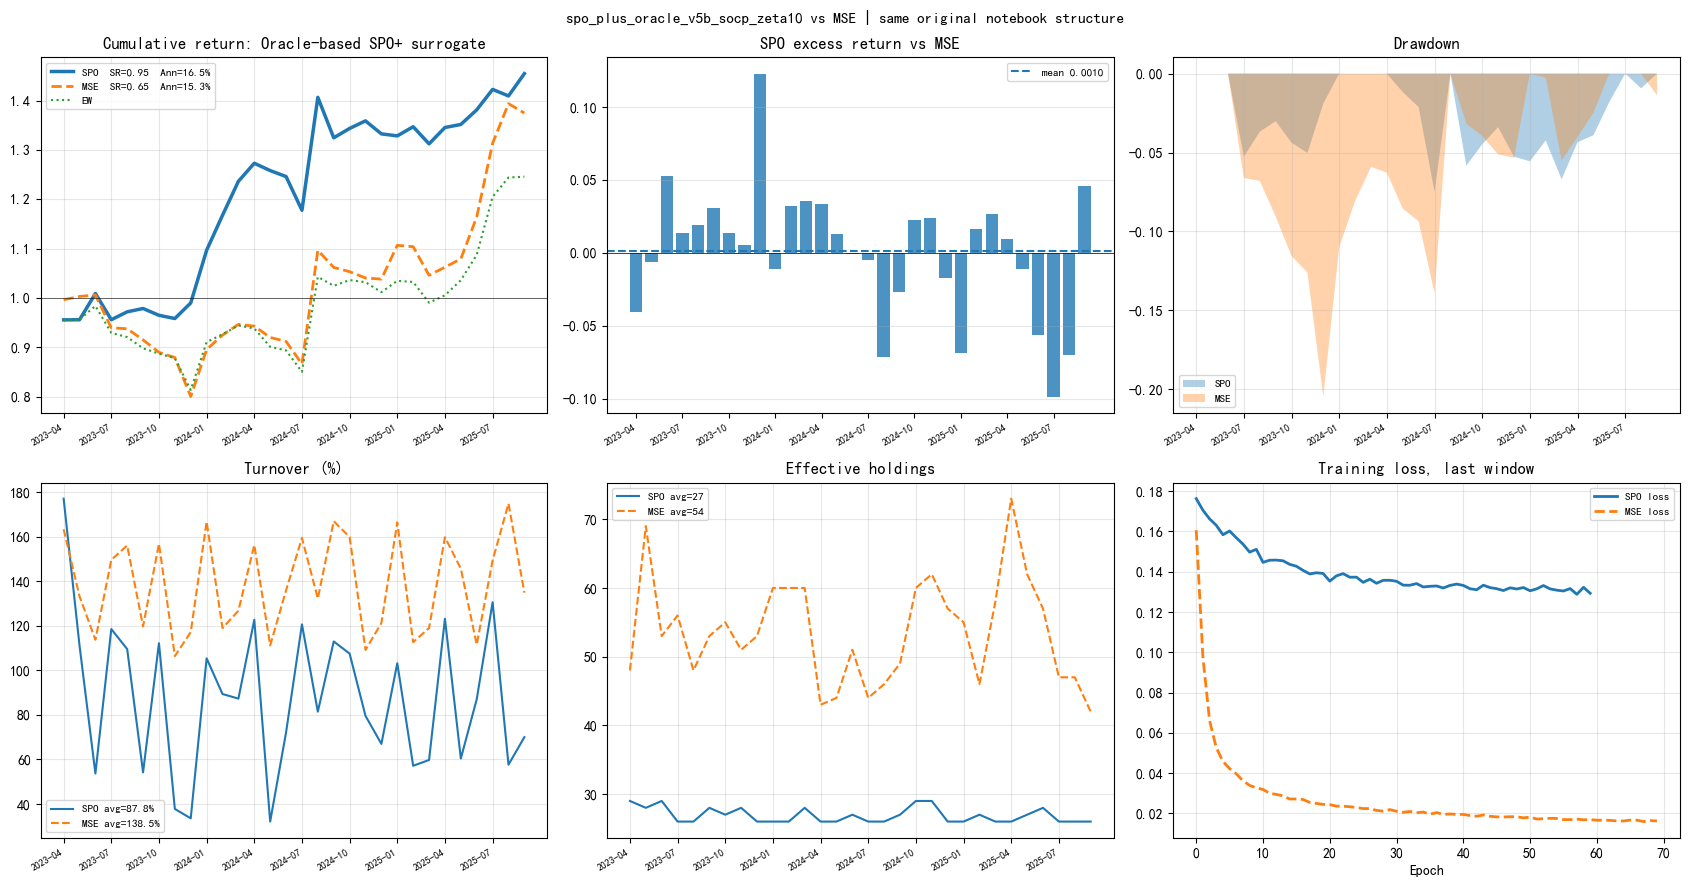

In [12]:
N_TEST = len(r_spo)
x = np.arange(N_TEST)
dlabels = [pd.Timestamp(d).strftime('%Y-%m') for d in res_spo['dates']]
step = max(1, N_TEST // 8)

cum_spo = np.cumprod(1 + r_spo)
cum_mse = np.cumprod(1 + r_mse)
cum_bch = np.cumprod(1 + r_bench)

fig, axes = plt.subplots(2, 3, figsize=(17, 9))

ax = axes[0, 0]
ax.plot(cum_spo, lw=2.5, label=f"SPO  SR={m_spo['Sharpe']:.2f}  Ann={m_spo['Ann_Ret']:.1%}")
ax.plot(cum_mse, lw=2.0, ls='--', label=f"MSE  SR={m_mse['Sharpe']:.2f}  Ann={m_mse['Ann_Ret']:.1%}")
ax.plot(cum_bch, lw=1.5, ls=':', label='EW')
ax.axhline(1, color='k', lw=0.4)
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set_title(f'Cumulative return: {SPO_LOSS_LABEL}')
ax.set_xticks(x[::step]); ax.set_xticklabels(dlabels[::step], rotation=30, ha='right', fontsize=7)

ax = axes[0, 1]
excess = r_spo - r_mse
ax.bar(x, excess, alpha=0.8)
ax.axhline(excess.mean(), ls='--', lw=1.5, label=f'mean {excess.mean():.4f}')
ax.axhline(0, color='k', lw=0.5)
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
ax.set_title('SPO excess return vs MSE')
ax.set_xticks(x[::step]); ax.set_xticklabels(dlabels[::step], rotation=30, ha='right', fontsize=7)

def dd_s(c):
    return (c / np.maximum.accumulate(c)) - 1

ax = axes[0, 2]
ax.fill_between(x, 0, dd_s(cum_spo), alpha=0.35, label='SPO')
ax.fill_between(x, 0, dd_s(cum_mse), alpha=0.35, label='MSE')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set_title('Drawdown')
ax.set_xticks(x[::step]); ax.set_xticklabels(dlabels[::step], rotation=30, ha='right', fontsize=7)

ax = axes[1, 0]
to_spo = calc_turnover(res_spo['weights'])
to_mse = calc_turnover(res_mse['weights'])
ax.plot(to_spo * 100, lw=1.5, label=f'SPO avg={to_spo.mean():.1%}')
ax.plot(to_mse * 100, lw=1.5, ls='--', label=f'MSE avg={to_mse.mean():.1%}')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set_title('Turnover (%)')
ax.set_xticks(x[::step]); ax.set_xticklabels(dlabels[::step], rotation=30, ha='right', fontsize=7)

ax = axes[1, 1]
eff_spo = [(w > 0.001).sum() for w in res_spo['weights']]
eff_mse = [(w > 0.001).sum() for w in res_mse['weights']]
ax.plot(eff_spo, lw=1.5, label=f'SPO avg={np.mean(eff_spo):.0f}')
ax.plot(eff_mse, lw=1.5, ls='--', label=f'MSE avg={np.mean(eff_mse):.0f}')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set_title('Effective holdings')
ax.set_xticks(x[::step]); ax.set_xticklabels(dlabels[::step], rotation=30, ha='right', fontsize=7)

ax = axes[1, 2]
if res_spo['loss_curves']:
    ax.plot(res_spo['loss_curves'][-1], lw=2, label='SPO loss')
if res_mse['loss_curves']:
    ax.plot(res_mse['loss_curves'][-1], lw=2, ls='--', label='MSE loss')
ax.legend(fontsize=8); ax.grid(alpha=0.3); ax.set_xlabel('Epoch')
ax.set_title('Training loss, last window')

plt.suptitle(f'{SPO_RUN_NAME} vs MSE | same original notebook structure', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()
